In [1]:
# Cell 1 — Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('spiff_data2.csv', index_col=0)
cols = ['gurkor','guitars','slingshots','stocks','sugar','water','tranquillity']

# Clean spike artifacts (value = 1000)
for col in cols:
    df.loc[df[col] > 100, col] = np.nan

In [2]:
# Cell 2 — Identify observed regions & compute log-returns

for col in cols:
    last_valid = df[col].last_valid_index()
    first_valid = df[col].first_valid_index()
    n_obs = df[col].loc[first_valid:last_valid].notna().sum()
    n_gap = df[col].loc[first_valid:last_valid].isna().sum()
    print(f'{col}: rows {first_valid}–{last_valid}, observed={n_obs}, internal gap={n_gap}')

# For each series: take observed data (drop internal gap), compute log-returns
observed = {}
log_ret = {}
for col in cols:
    s = df[col].loc[:df[col].last_valid_index()].dropna()
    observed[col] = s
    log_ret[col] = np.log(s).diff().dropna()

gurkor: rows 0–5255, observed=5201, internal gap=55
guitars: rows 0–5255, observed=5201, internal gap=55
slingshots: rows 0–5255, observed=5201, internal gap=55
stocks: rows 0–5255, observed=5201, internal gap=55
sugar: rows 0–5255, observed=5201, internal gap=55
water: rows 0–5255, observed=5201, internal gap=55
tranquillity: rows 0–5255, observed=5201, internal gap=55


In [3]:
# Cell 3 — Stationarity check & return summary stats

from statsmodels.tsa.stattools import adfuller

rows = []
for col in cols:
    r = log_ret[col]
    adf_stat, adf_p, *_ = adfuller(r, maxlag=20, autolag='AIC')
    rows.append({
        'series': col,
        'n': len(r),
        'mean': r.mean(),
        'std': r.std(),
        'skew': r.skew(),
        'kurt': r.kurt(),
        'ADF_stat': adf_stat,
        'ADF_p': adf_p
    })

summary = pd.DataFrame(rows).set_index('series')
summary.round(5)

,n,mean,std,skew,kurt,ADF_stat,ADF_p
series,,,,,,,
gurkor,5200,0.00016,0.00395,-0.14812,3.49293,-53.11264,0.0
guitars,5200,0.00020,0.01494,-0.07537,5.63923,-29.26203,0.0
slingshots,5200,0.00021,0.01478,-0.42050,6.46926,-19.12909,0.0
stocks,5200,-0.00009,0.01496,-0.13124,0.09615,-72.17930,0.0
sugar,5200,-0.00004,0.01524,-0.25108,10.63255,-36.77856,0.0
water,5200,0.00016,0.00352,-0.25402,2.25096,-43.14604,0.0
tranquillity,5200,0.00009,0.01263,-0.23949,3.08080,-73.78708,0.0


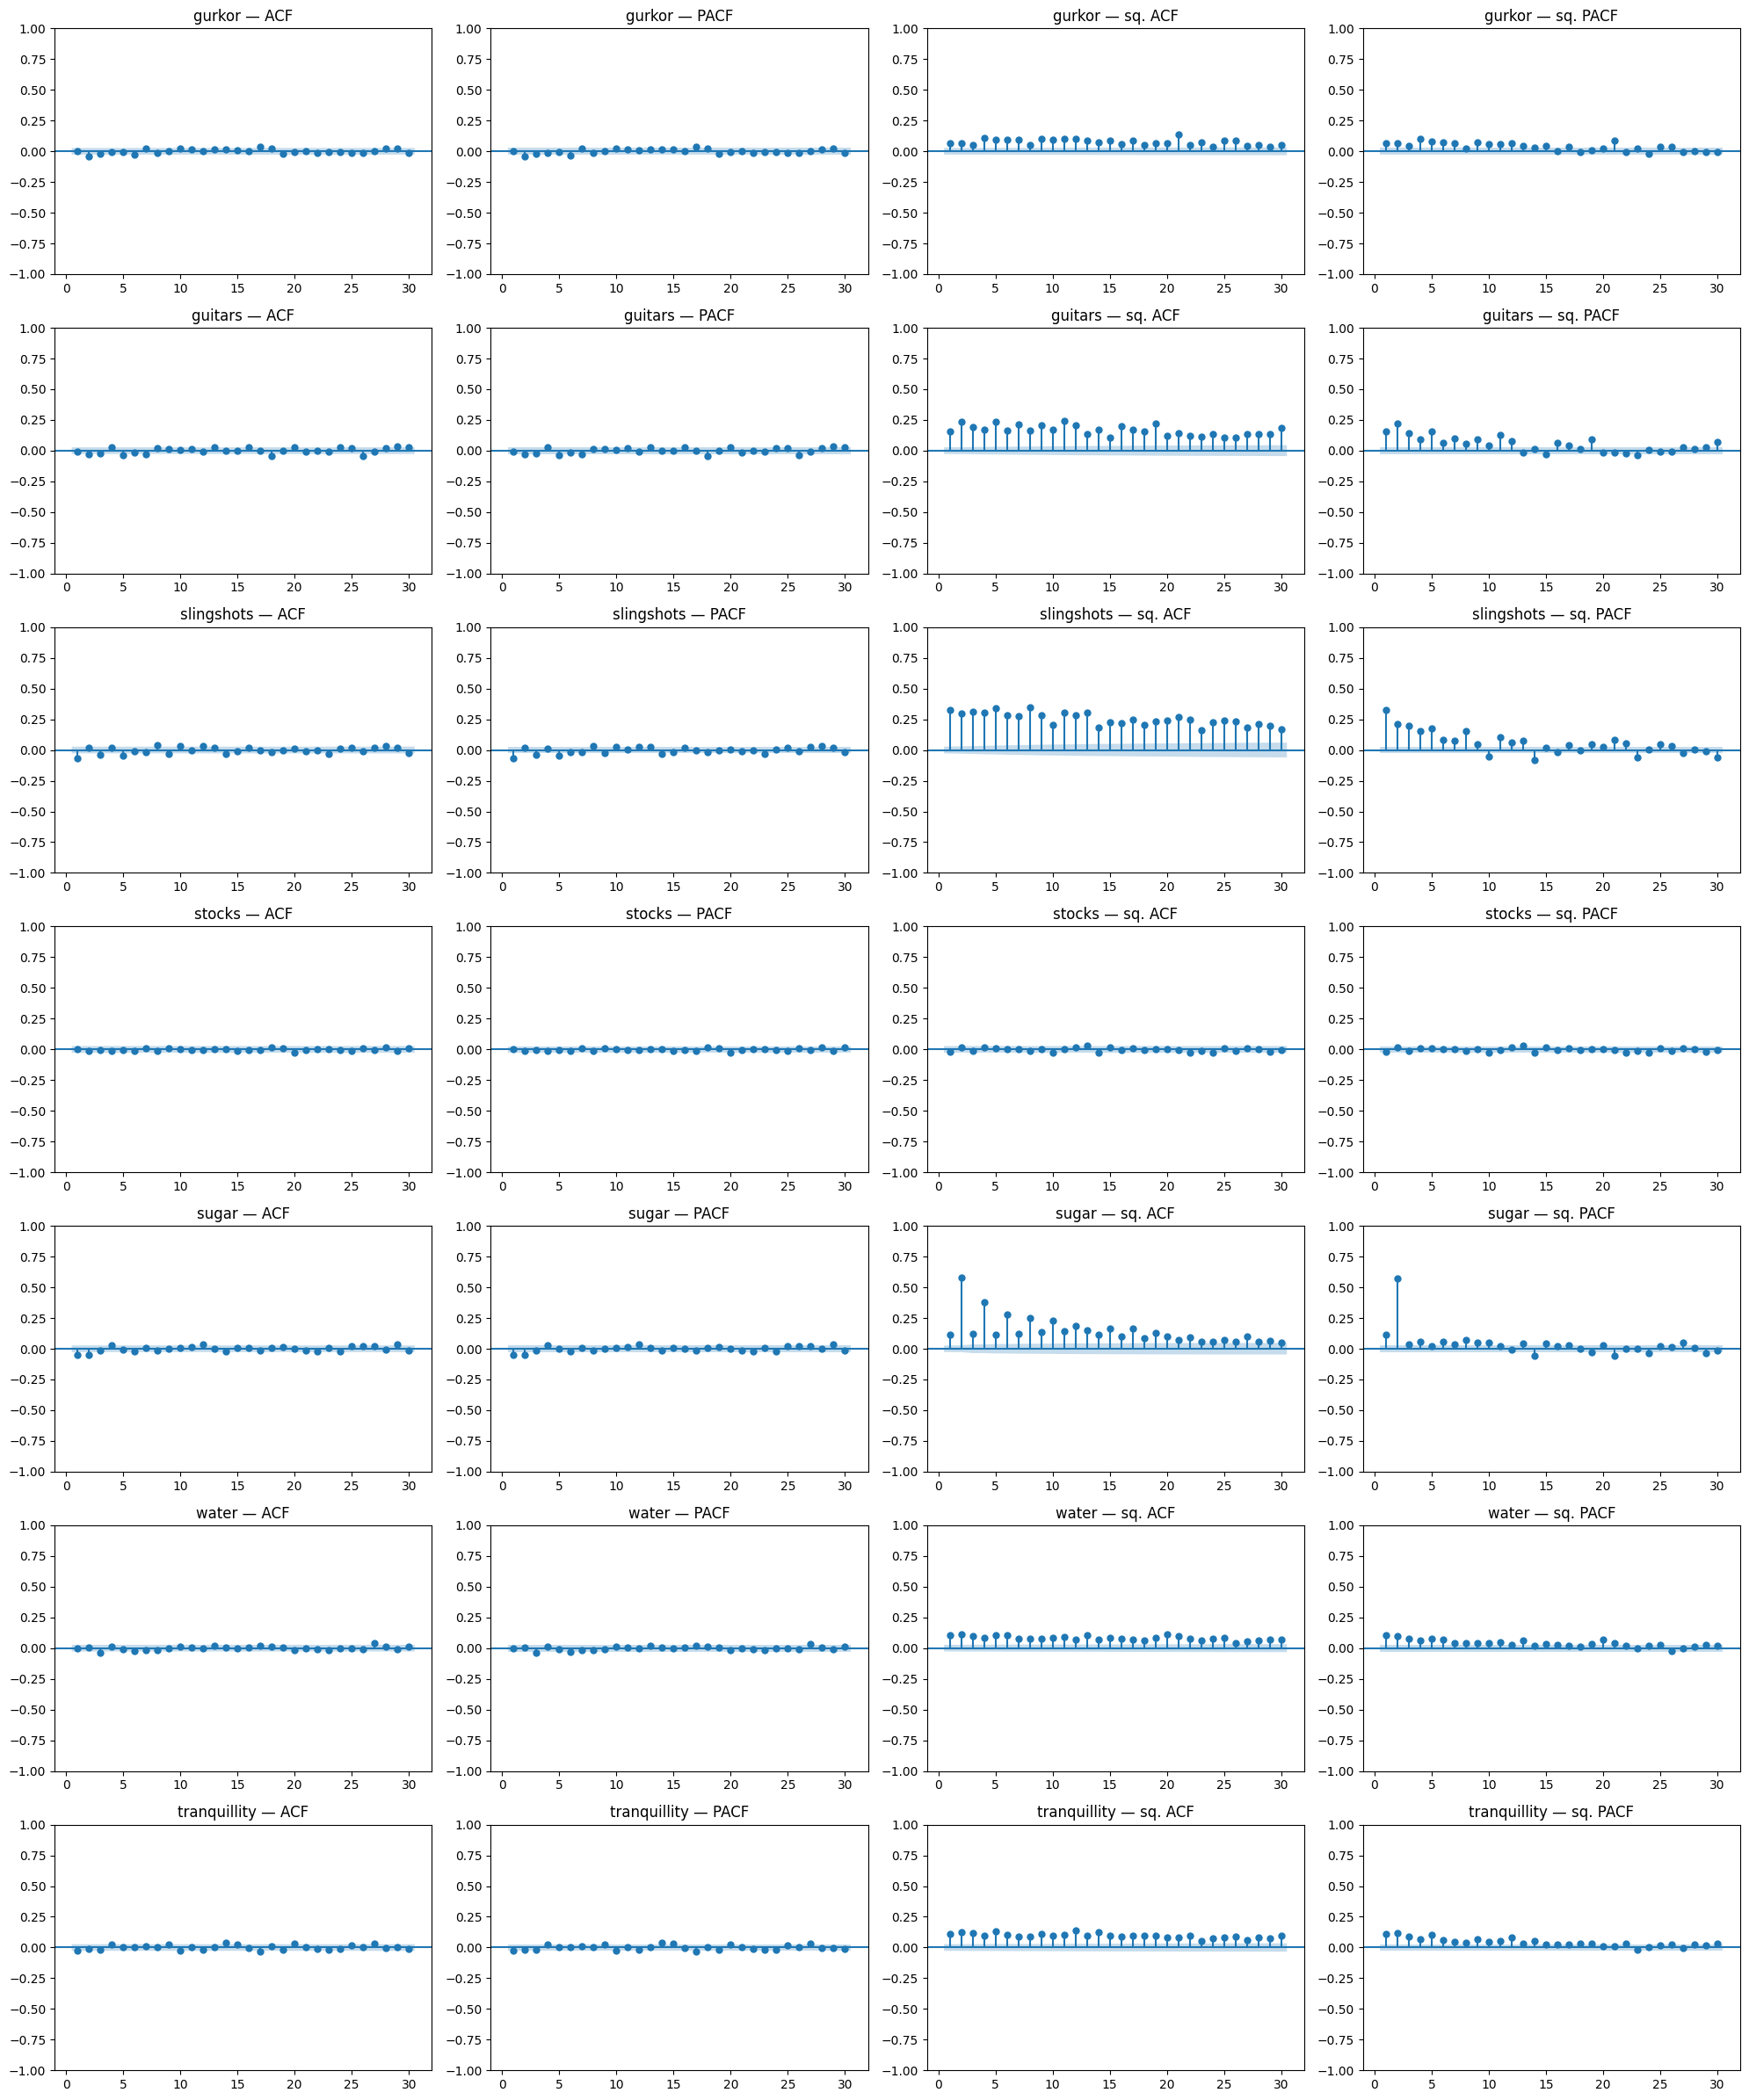

In [4]:
# Cell 4 — ACF/PACF plots for returns and squared returns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(len(cols), 4, figsize=(20, 24))

for i, col in enumerate(cols):
    r = log_ret[col]
    plot_acf(r,    ax=axes[i, 0], lags=30, zero=False, title=f'{col} — ACF')
    plot_pacf(r,   ax=axes[i, 1], lags=30, zero=False, title=f'{col} — PACF')
    plot_acf(r**2, ax=axes[i, 2], lags=30, zero=False, title=f'{col} — sq. ACF')
    plot_pacf(r**2,ax=axes[i, 3], lags=30, zero=False, title=f'{col} — sq. PACF')

plt.tight_layout()
plt.show()

In [5]:
# Cell 5 — Fit GARCH(1,1) with t-innovations to each series

from arch import arch_model

fits = {}

for col in cols:
    r = log_ret[col] * 100  # percentage returns for numerical stability
    model = arch_model(r, mean='Constant', vol='Garch', p=1, q=1, dist='t')
    fit = model.fit(disp='off')
    fits[col] = fit
    print(f'\n=== {col} ===')
    print(f'mu = {fit.params["mu"]:.4f}, omega = {fit.params["omega"]:.6f}, '
          f'alpha = {fit.params["alpha[1]"]:.4f}, beta = {fit.params["beta[1]"]:.4f}, '
          f'nu = {fit.params["nu"]:.2f}')
    print(f'alpha+beta = {fit.params["alpha[1]"] + fit.params["beta[1]"]:.4f}')


=== gurkor ===
mu = 0.0175, omega = 0.000803, alpha = 0.0355, beta = 0.9597, nu = 6.87
alpha+beta = 0.9953

=== guitars ===
mu = 0.0872, omega = 0.012288, alpha = 0.0759, beta = 0.9217, nu = 6.54
alpha+beta = 0.9976

=== slingshots ===
mu = 0.0817, omega = 0.014431, alpha = 0.0982, beta = 0.8995, nu = 7.90
alpha+beta = 0.9976

=== stocks ===
mu = -0.0075, omega = 0.071932, alpha = 0.0000, beta = 0.9679, nu = 77.99
alpha+beta = 0.9679

=== sugar ===
mu = 0.0389, omega = 0.021763, alpha = 0.0674, beta = 0.9255, nu = 6.20
alpha+beta = 0.9929

=== water ===
mu = 0.0207, omega = 0.001015, alpha = 0.0420, beta = 0.9502, nu = 7.62
alpha+beta = 0.9923

=== tranquillity ===
mu = 0.0072, omega = 0.012528, alpha = 0.0446, beta = 0.9480, nu = 6.57
alpha+beta = 0.9926


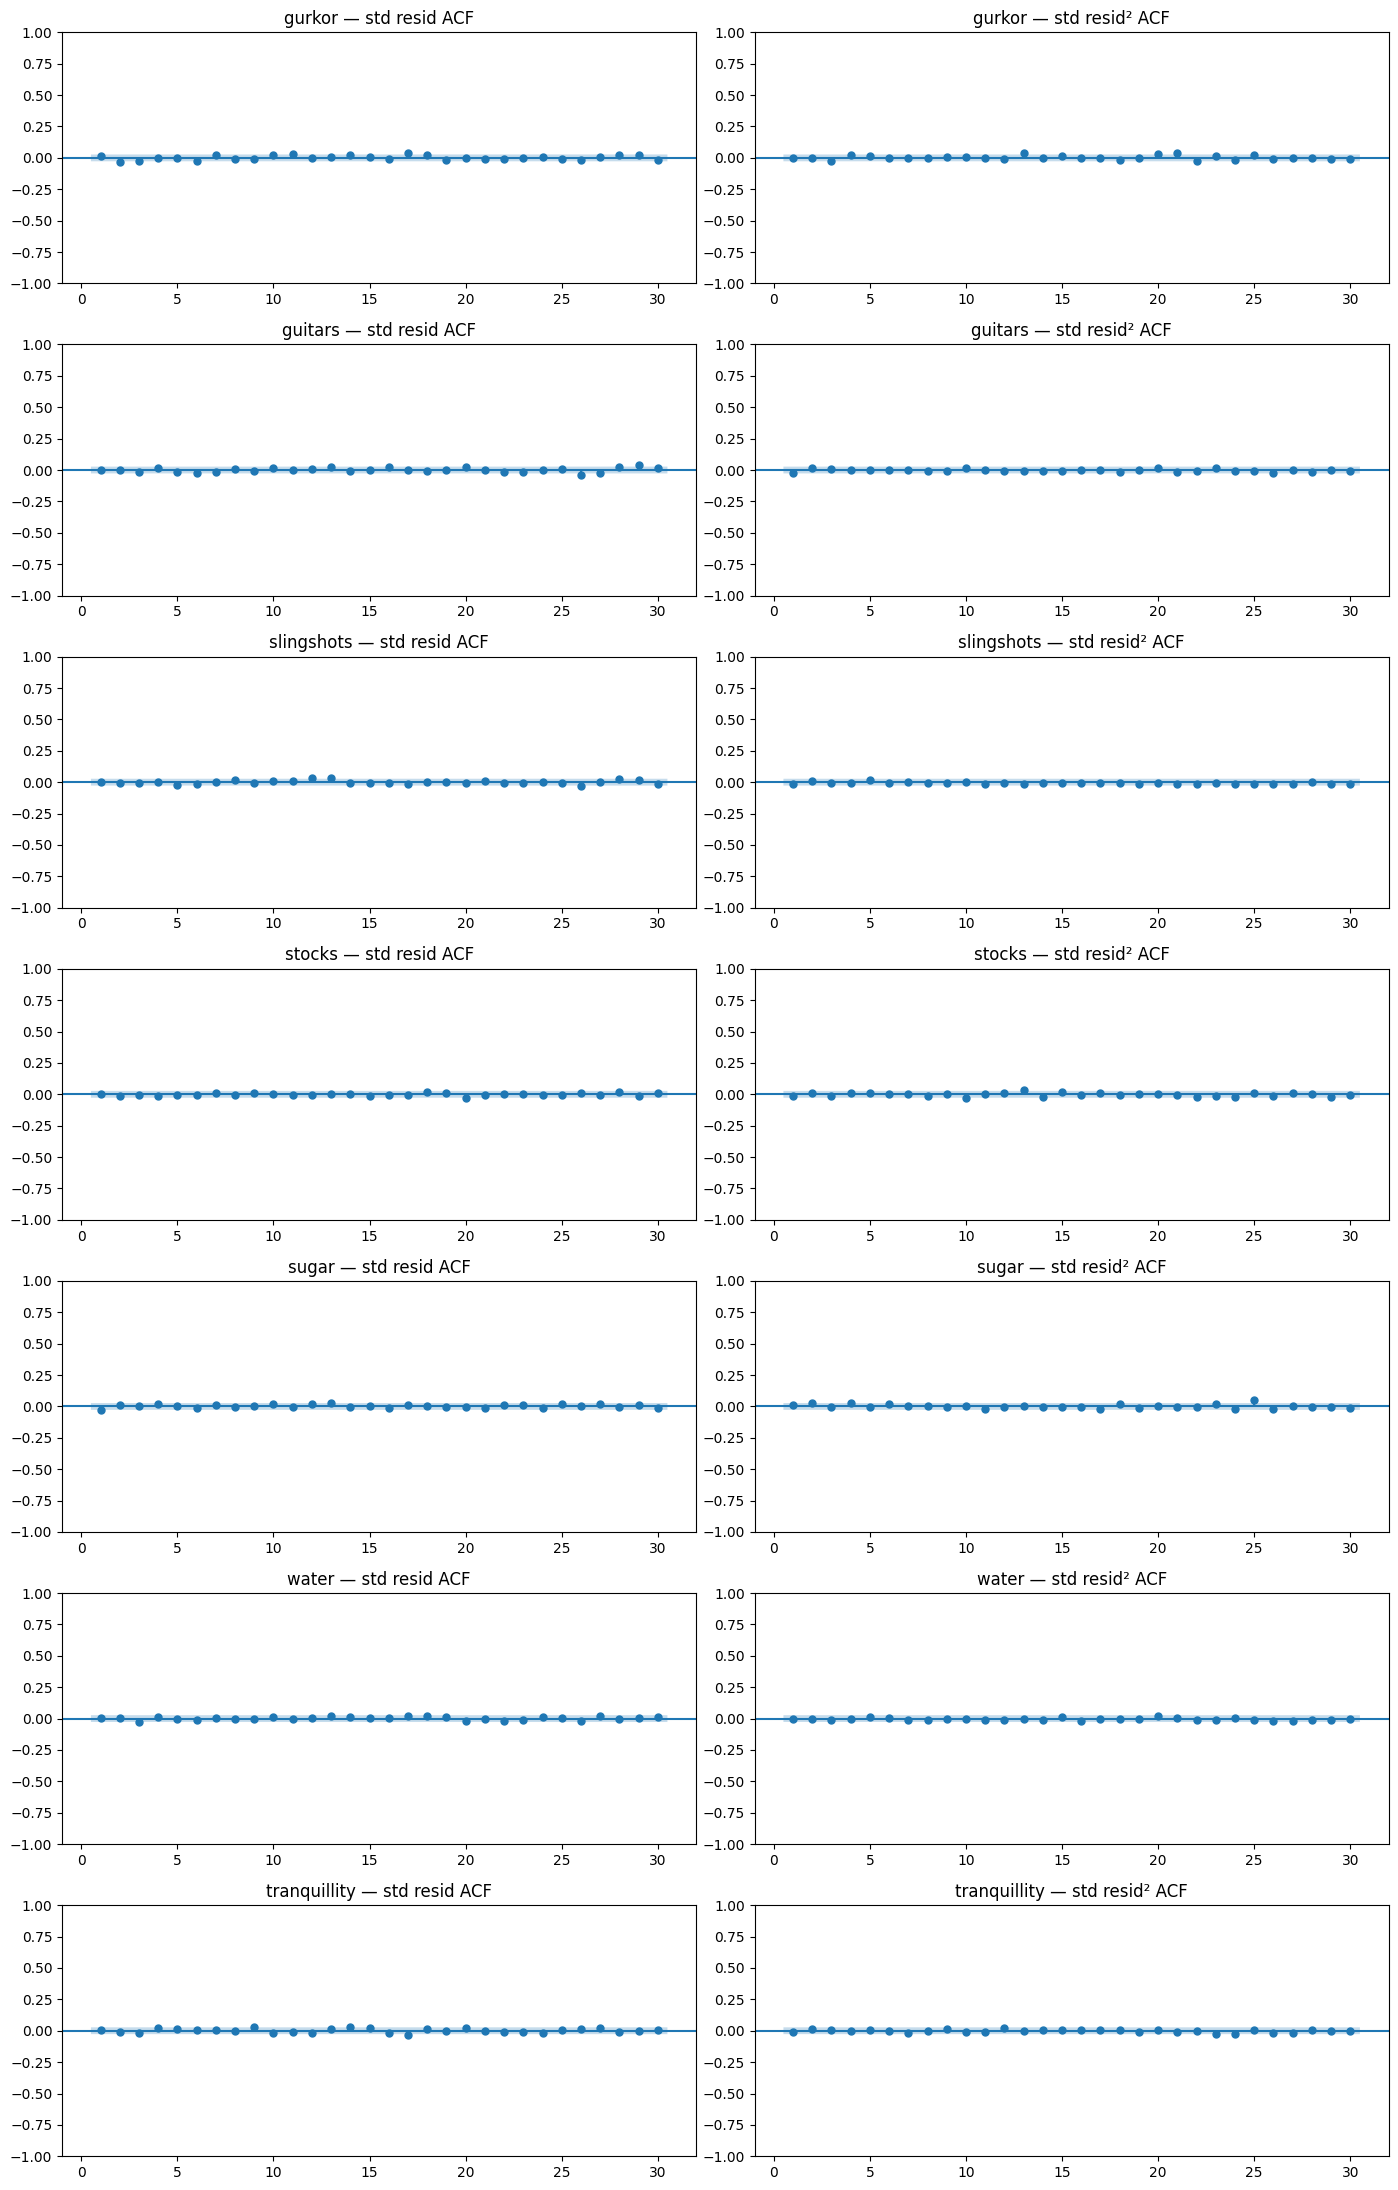


gurkor:
  Resid   LB p-values: lag10=0.080, lag20=0.019
  Resid²  LB p-values: lag10=0.505, lag20=0.183

guitars:
  Resid   LB p-values: lag10=0.671, lag20=0.605
  Resid²  LB p-values: lag10=0.822, lag20=0.964

slingshots:
  Resid   LB p-values: lag10=0.803, lag20=0.516
  Resid²  LB p-values: lag10=0.980, lag20=0.987

stocks:
  Resid   LB p-values: lag10=0.968, lag20=0.940
  Resid²  LB p-values: lag10=0.546, lag20=0.354

sugar:
  Resid   LB p-values: lag10=0.437, lag20=0.653
  Resid²  LB p-values: lag10=0.338, lag20=0.475

water:
  Resid   LB p-values: lag10=0.690, lag20=0.716
  Resid²  LB p-values: lag10=0.958, lag20=0.946

tranquillity:
  Resid   LB p-values: lag10=0.232, lag20=0.043
  Resid²  LB p-values: lag10=0.914, lag20=0.992


In [6]:
# Cell 6 — Diagnostics: standardized residuals

from statsmodels.stats.diagnostic import acorr_ljungbox

fig, axes = plt.subplots(len(cols), 2, figsize=(14, 22))

for i, col in enumerate(cols):
    std_resid = fits[col].std_resid.dropna()
    
    plot_acf(std_resid,    ax=axes[i, 0], lags=30, zero=False, title=f'{col} — std resid ACF')
    plot_acf(std_resid**2, ax=axes[i, 1], lags=30, zero=False, title=f'{col} — std resid² ACF')

plt.tight_layout()
plt.show()

# Ljung-Box on standardized residuals and squared residuals
for col in cols:
    std_resid = fits[col].std_resid.dropna()
    lb_resid = acorr_ljungbox(std_resid, lags=[10, 20], return_df=True)
    lb_sq = acorr_ljungbox(std_resid**2, lags=[10, 20], return_df=True)
    print(f'\n{col}:')
    print(f'  Resid   LB p-values: lag10={lb_resid["lb_pvalue"].iloc[0]:.3f}, lag20={lb_resid["lb_pvalue"].iloc[1]:.3f}')
    print(f'  Resid²  LB p-values: lag10={lb_sq["lb_pvalue"].iloc[0]:.3f}, lag20={lb_sq["lb_pvalue"].iloc[1]:.3f}')

In [7]:
# Cell 7 — Monte Carlo simulation: 200-step-ahead forecast

n_sim = 10000
n_steps = 200

forecasts = {}

for col in cols:
    fit = fits[col]
    last_price = observed[col].iloc[-1]
    
    sim = fit.forecast(horizon=n_steps, method='simulation', simulations=n_sim)
    
    # Simulated returns are in percentage terms — convert back
    # Shape: (n_sim, n_steps)
    sim_returns = sim.simulations.values[-1, :, :] / 100  # last row = forecast from end of sample
    
    # Cumulate log-returns to get log-price paths, then exponentiate
    cum_returns = np.cumsum(sim_returns, axis=1)
    price_paths = last_price * np.exp(cum_returns)
    
    median = np.median(price_paths, axis=0)
    lo5 = np.percentile(price_paths, 5, axis=0)
    hi95 = np.percentile(price_paths, 95, axis=0)
    
    forecasts[col] = {
        'median': median,
        'lo5': lo5,
        'hi95': hi95,
        'paths': price_paths
    }

print('Simulation complete.')

Simulation complete.


In [8]:
# Cell 8 — Backtest: hold out last 200 observed points, forecast, compare

holdout = 200

bt_results = []

for col in cols:
    s = observed[col]
    train = s.iloc[:-holdout]
    actual = s.iloc[-holdout:].values
    
    # Fit on training data
    r_train = (np.log(train).diff().dropna()) * 100
    model = arch_model(r_train, mean='Constant', vol='Garch', p=1, q=1, dist='t')
    bt_fit = model.fit(disp='off')
    
    # Simulate
    sim = bt_fit.forecast(horizon=holdout, method='simulation', simulations=n_sim)
    sim_returns = sim.simulations.values[-1, :, :] / 100
    cum_returns = np.cumsum(sim_returns, axis=1)
    price_paths = train.iloc[-1] * np.exp(cum_returns)
    
    median = np.median(price_paths, axis=0)
    lo5 = np.percentile(price_paths, 5, axis=0)
    hi95 = np.percentile(price_paths, 95, axis=0)
    
    # Metrics
    rmse = np.sqrt(np.mean((median - actual)**2))
    mae = np.mean(np.abs(median - actual))
    coverage = np.mean((actual >= lo5) & (actual <= hi95))
    
    # Directional accuracy (on returns)
    actual_dir = np.diff(actual) > 0
    median_dir = np.diff(median) > 0
    dir_acc = np.mean(actual_dir == median_dir)
    
    bt_results.append({
        'series': col, 'RMSE': rmse, 'MAE': mae,
        '90% coverage': coverage, 'dir_accuracy': dir_acc
    })

bt_df = pd.DataFrame(bt_results).set_index('series')
bt_df.round(3)

,RMSE,MAE,90% coverage,dir_accuracy
series,,,,
gurkor,0.176,0.146,0.980,0.513
guitars,0.200,0.144,1.000,0.563
slingshots,0.205,0.172,1.000,0.553
stocks,0.971,0.814,0.965,0.492
sugar,0.498,0.362,0.705,0.497
water,0.086,0.071,0.990,0.492
tranquillity,0.951,0.765,0.895,0.487


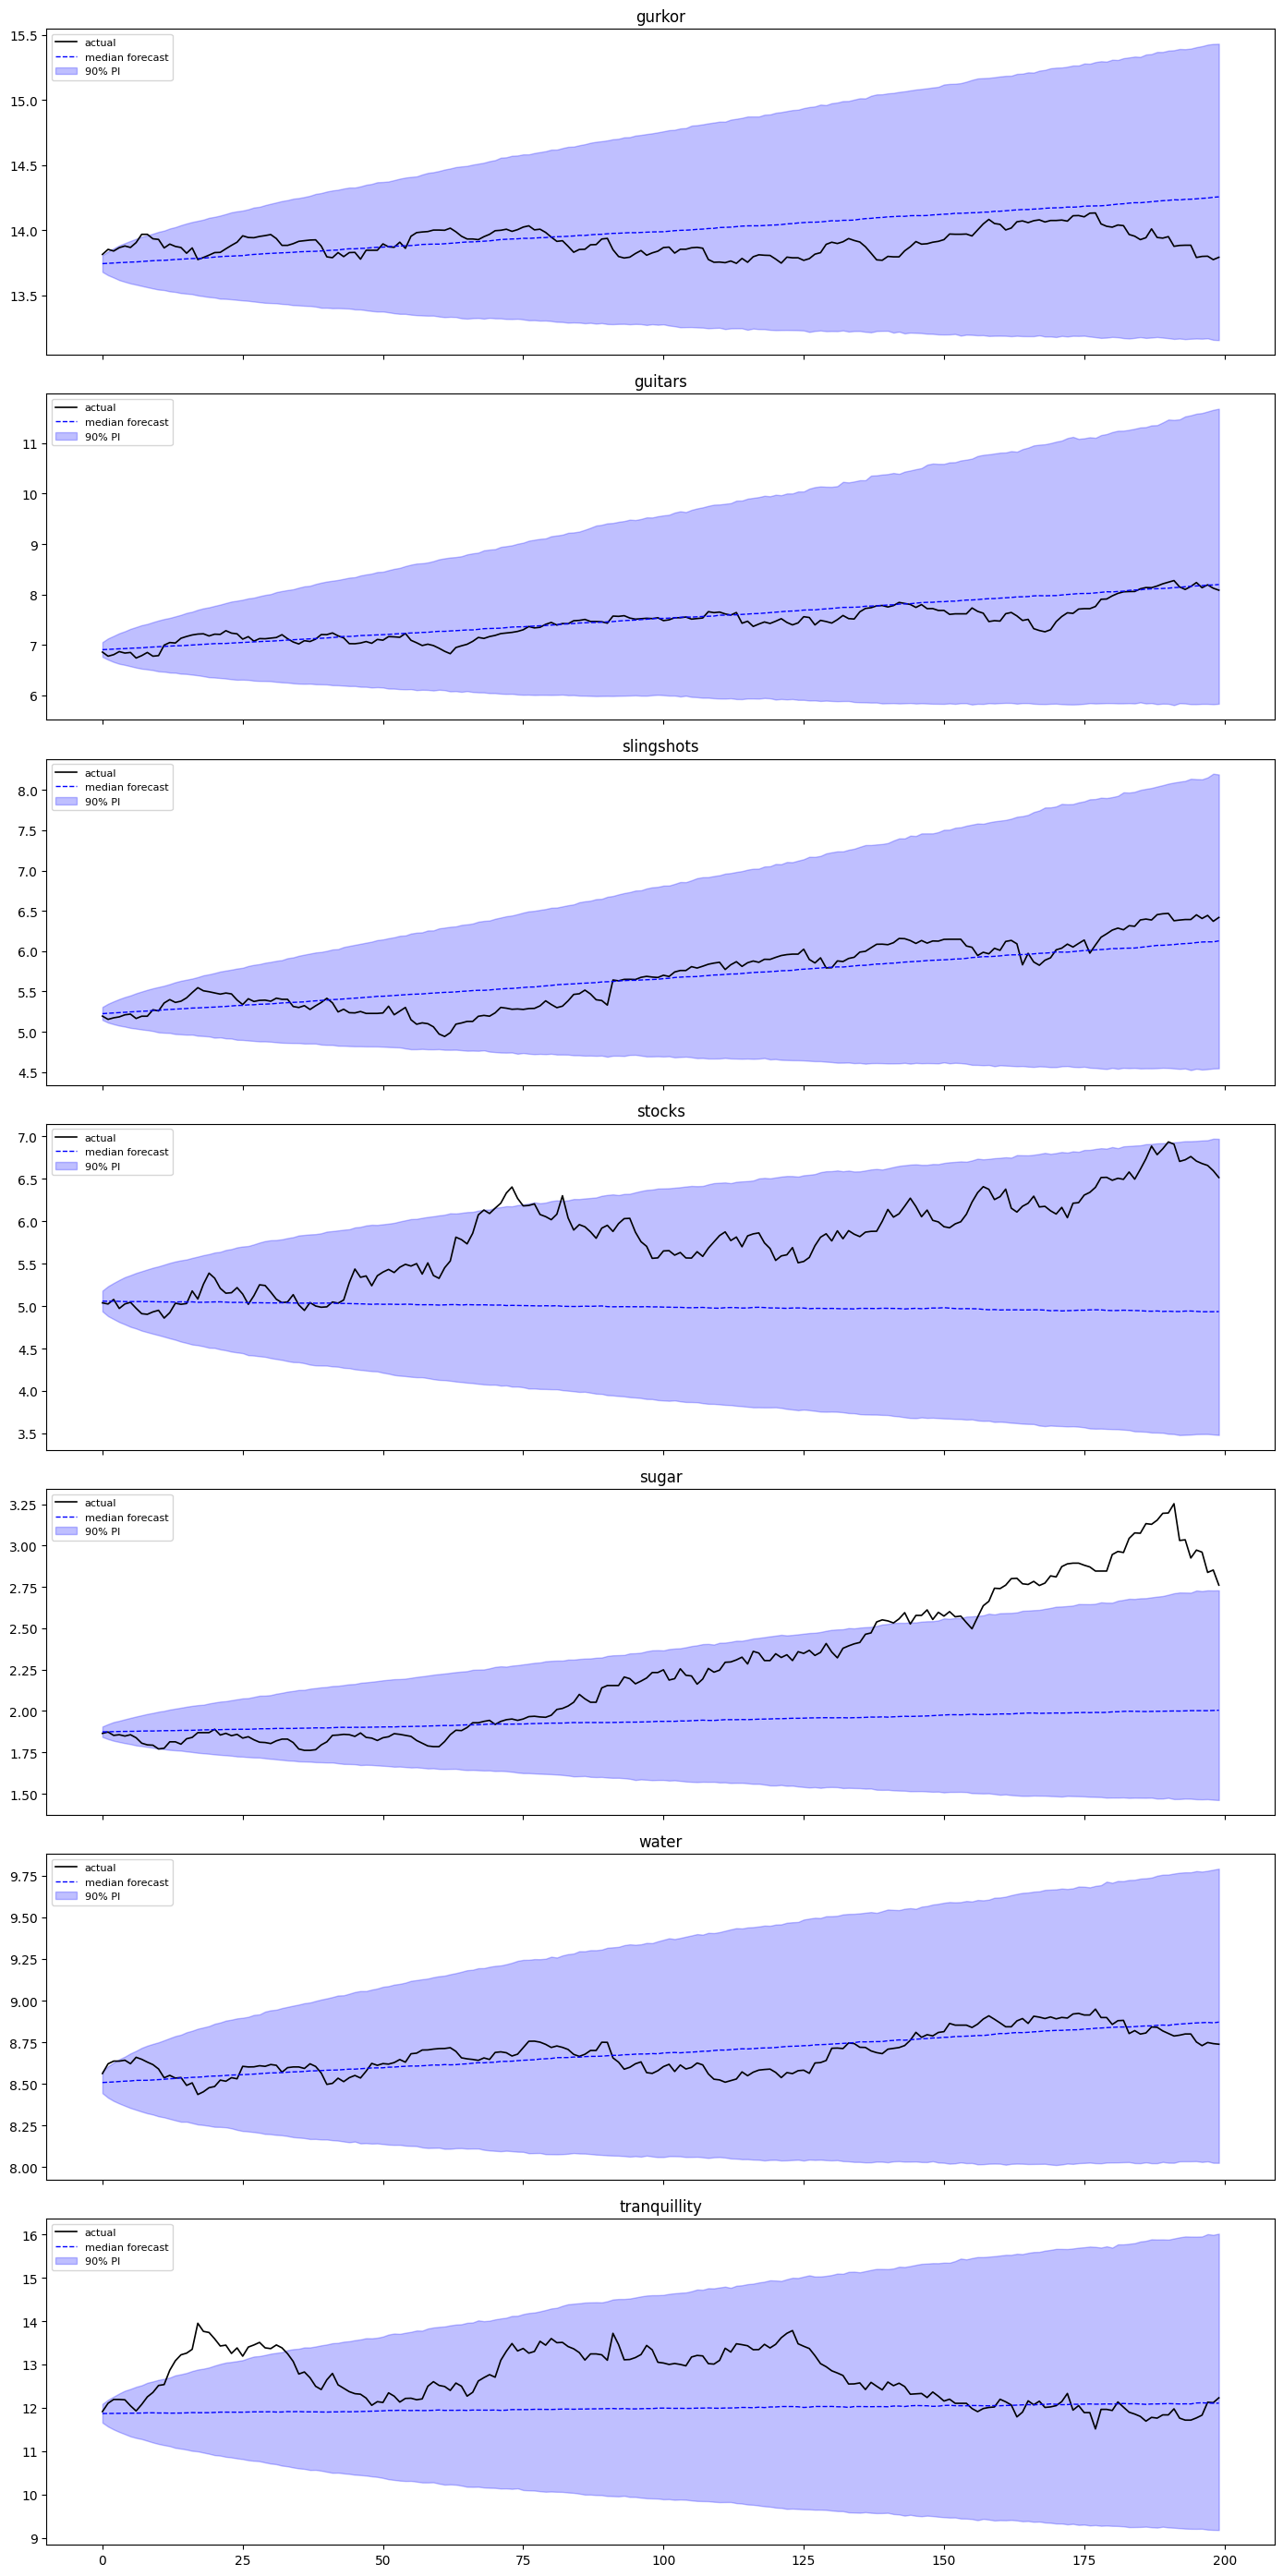

In [9]:
# Cell 9 — Backtest plots: actual vs forecast with prediction intervals

fig, axes = plt.subplots(len(cols), 1, figsize=(14, 28), sharex=True)

for i, col in enumerate(cols):
    ax = axes[i]
    s = observed[col]
    actual = s.iloc[-holdout:].values
    
    # Re-extract backtest forecast (recompute from bt loop or store — here we recompute quickly)
    train = s.iloc[:-holdout]
    r_train = (np.log(train).diff().dropna()) * 100
    model = arch_model(r_train, mean='Constant', vol='Garch', p=1, q=1, dist='t')
    bt_fit = model.fit(disp='off')
    sim = bt_fit.forecast(horizon=holdout, method='simulation', simulations=n_sim)
    sim_returns = sim.simulations.values[-1, :, :] / 100
    price_paths = train.iloc[-1] * np.exp(np.cumsum(sim_returns, axis=1))
    
    median = np.median(price_paths, axis=0)
    lo5 = np.percentile(price_paths, 5, axis=0)
    hi95 = np.percentile(price_paths, 95, axis=0)
    
    x = np.arange(holdout)
    ax.plot(x, actual, 'k-', lw=1.2, label='actual')
    ax.plot(x, median, 'b--', lw=1, label='median forecast')
    ax.fill_between(x, lo5, hi95, alpha=0.25, color='blue', label='90% PI')
    ax.set_title(col)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

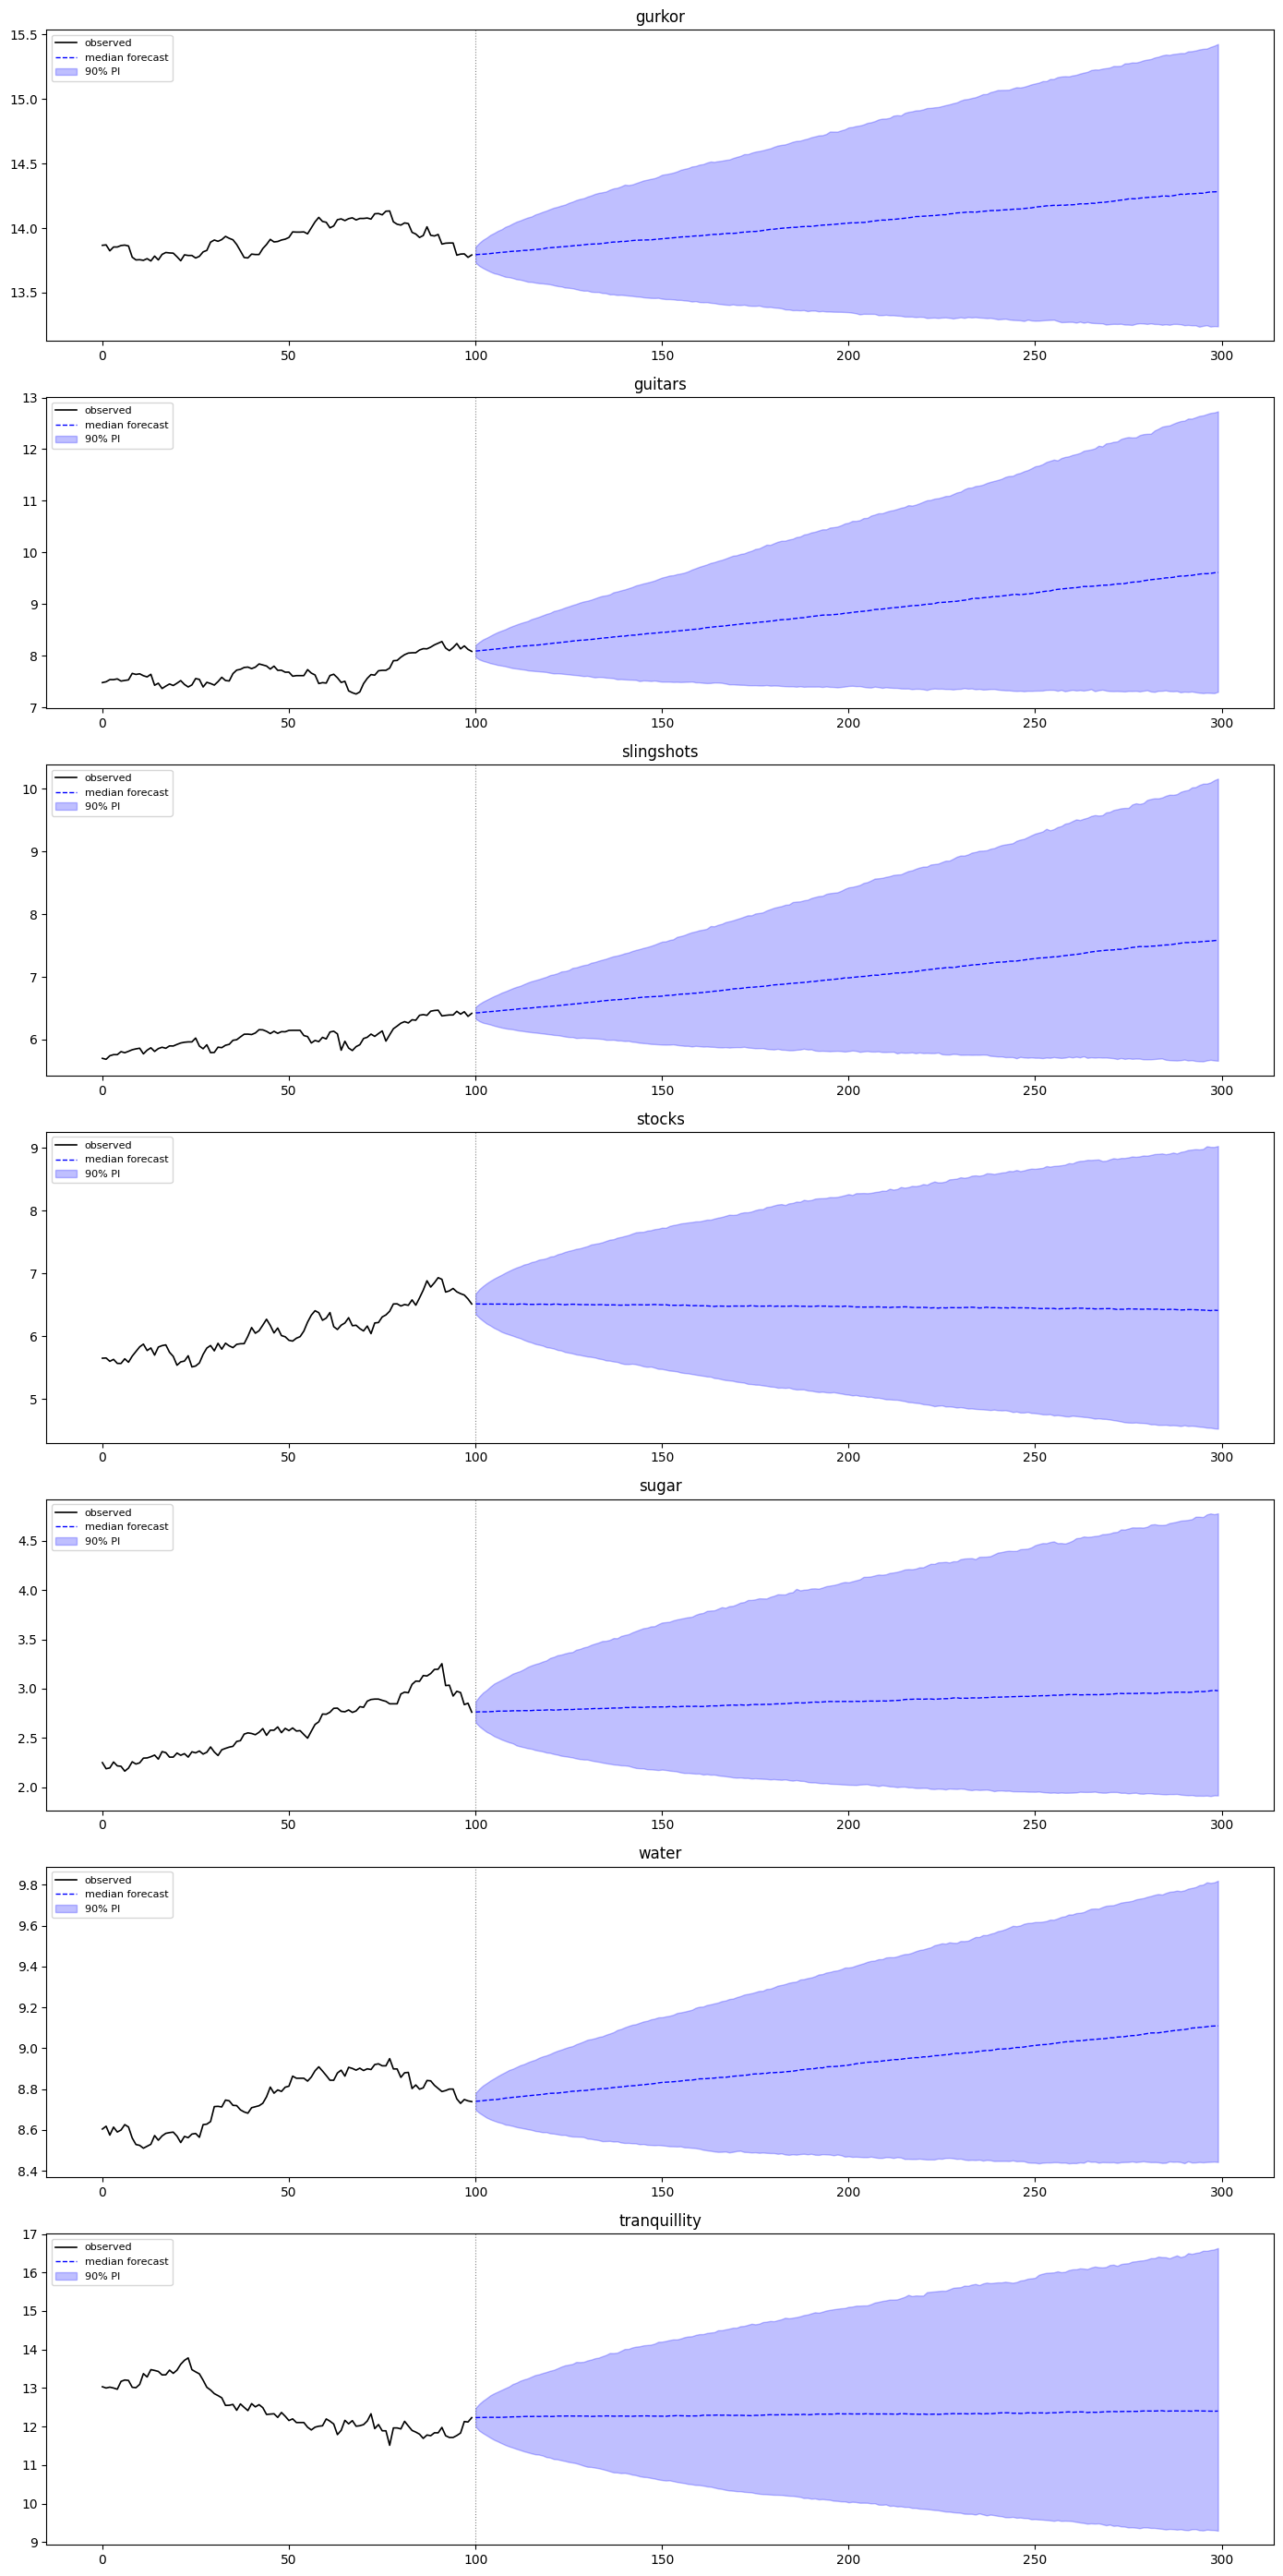

In [10]:
# Cell 10 — Final forecast plots: 200-step extrapolation from end of observed data

fig, axes = plt.subplots(len(cols), 1, figsize=(14, 28), sharex=False)

context = 100  # show last 100 observed points for context

for i, col in enumerate(cols):
    ax = axes[i]
    s = observed[col]
    
    # Context
    ctx = s.iloc[-context:].values
    x_ctx = np.arange(context)
    
    # Forecast
    fc = forecasts[col]
    x_fc = np.arange(context, context + n_steps)
    
    ax.plot(x_ctx, ctx, 'k-', lw=1.2, label='observed')
    ax.plot(x_fc, fc['median'], 'b--', lw=1, label='median forecast')
    ax.fill_between(x_fc, fc['lo5'], fc['hi95'], alpha=0.25, color='blue', label='90% PI')
    ax.axvline(x=context, color='grey', ls=':', lw=0.8)
    ax.set_title(col)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## Using Task 1 Insights for Extrapolation

**Series characteristics that shape our forecasting choices:**

| Series | Key Task 1 finding | Implication for extrapolation |
|---|---|---|
| stocks | No ARCH effects (α≈0), ν≈78 (near-Gaussian), iid-like | GARCH(1,1) degenerates to constant-variance RW — this is appropriate and no improvement from complexity |
| sugar | Excess kurtosis ≈ 10.6, strong ARCH | t(ν=6.2) only generates kurtosis ≈ 2.7 → parametric PI too narrow → **use FHS** |
| gurkor, water | Low volatility (σ≈0.35–0.39%), positively correlated (ρ=+0.58) | A bivariate DCC-GARCH could reduce forecast variance; univariate GARCH is used here as a sound baseline |
| guitars, slingshots | High volatility (σ≈1.5%), positively correlated (ρ=+0.53) | Same as above |
| All except stocks | Strong ARCH effects confirmed | GARCH(1,1) with volatility clustering is the right model family |

**Why FHS over parametric simulation:**

The parametric approach (Cell 7) draws innovations from the fitted t-distribution.
For sugar, the t-distribution's theoretical kurtosis is `3 + 6/(ν−4) ≈ 5.7` (with ν=6.2),
well below the empirical kurtosis of 10.6.
This makes the simulated return distributions too light-tailed, producing prediction intervals
that are systematically too narrow — confirmed by only 70.5% backtested coverage against a nominal 90%.

**Filtered Historical Simulation (FHS)** keeps the GARCH variance dynamics but replaces the
parametric t-distribution with the empirical distribution of standardized residuals.
This is a standard technique in financial risk management (Barone-Adesi et al., 1999)
that naturally captures fat tails, skewness, and any other distributional anomalies
without additional parametric assumptions.

In [11]:
# Cell 12 — Filtered Historical Simulation (FHS)
# Instead of drawing innovations from t(nu), we resample the empirical standardized residuals.
# This preserves the true tail behaviour without imposing a parametric shape.
#
# Motivation from Task 1:
#   sugar: empirical excess kurtosis ≈ 10.6;  t(nu=6.2) implies excess kurtosis ≈ 2.7
#          → parametric method systematically underestimates tail risk → 70.5% backtest coverage
#   stocks: alpha ≈ 0, nu ≈ 78 → near-iid, nearly Gaussian; GARCH degenerates to constant variance
#   All other series: strong ARCH effects confirmed → GARCH(1,1) structure is appropriate
#
# Procedure:
#   1. From the full-sample fitted GARCH, extract standardized residuals z_t = eps_t / sigma_t
#   2. For each Monte Carlo path, draw z ~ Empirical{z_1,...,z_T} (with replacement)
#   3. Propagate: r_{t+h} = (mu + sqrt(h) * z) / 100,  h_new = omega + alpha*h*z^2 + beta*h

np.random.seed(42)
forecasts_fhs = {}

for col in cols:
    fit        = fits[col]
    last_price = observed[col].iloc[-1]

    std_resid  = fit.std_resid.dropna().values         # empirical standardized residuals
    sigma_last = fit.conditional_volatility.iloc[-1]   # last conditional std (in %)
    h          = sigma_last ** 2                        # initial conditional variance (in %^2)

    mu    = fit.params['mu']
    omega = fit.params['omega']
    alpha = fit.params['alpha[1]']
    beta  = fit.params['beta[1]']

    # Vectorize over n_sim paths; loop sequentially over time (GARCH is path-dependent)
    h_vec     = np.full(n_sim, h)
    all_paths = np.zeros((n_sim, n_steps))

    for t in range(n_steps):
        z = np.random.choice(std_resid, size=n_sim)         # resample from empirical distribution
        all_paths[:, t] = (mu + np.sqrt(h_vec) * z) / 100  # decimal log-returns
        h_vec = omega + alpha * h_vec * z**2 + beta * h_vec # GARCH variance update

    cum_ret     = np.cumsum(all_paths, axis=1)
    price_paths = last_price * np.exp(cum_ret)

    forecasts_fhs[col] = {
        'median': np.median(price_paths, axis=0),
        'lo5':    np.percentile(price_paths,  5, axis=0),
        'hi95':   np.percentile(price_paths, 95, axis=0),
        'lo10':   np.percentile(price_paths, 10, axis=0),
        'hi90':   np.percentile(price_paths, 90, axis=0),
    }
    print(f'{col}: done')

print('\nFHS simulation complete.')

gurkor: done
guitars: done
slingshots: done
stocks: done
sugar: done
water: done
tranquillity: done

FHS simulation complete.


In [12]:
# Cell 13 — Backtest FHS: re-fit on train, simulate with empirical residuals, compare coverage

np.random.seed(42)
bt_fhs_results = []

for col in cols:
    s      = observed[col]
    train  = s.iloc[:-holdout]
    actual = s.iloc[-holdout:].values

    r_train = np.log(train).diff().dropna() * 100
    bt_fit  = arch_model(r_train, mean='Constant', vol='Garch', p=1, q=1, dist='t').fit(disp='off')

    std_resid  = bt_fit.std_resid.dropna().values
    sigma_last = bt_fit.conditional_volatility.iloc[-1]
    h          = sigma_last ** 2

    mu    = bt_fit.params['mu']
    omega = bt_fit.params['omega']
    alpha = bt_fit.params['alpha[1]']
    beta  = bt_fit.params['beta[1]']

    h_vec     = np.full(n_sim, h)
    all_paths = np.zeros((n_sim, holdout))

    for t in range(holdout):
        z = np.random.choice(std_resid, size=n_sim)
        all_paths[:, t] = (mu + np.sqrt(h_vec) * z) / 100
        h_vec = omega + alpha * h_vec * z**2 + beta * h_vec

    price_paths = train.iloc[-1] * np.exp(np.cumsum(all_paths, axis=1))
    median  = np.median(price_paths, axis=0)
    lo5     = np.percentile(price_paths,  5, axis=0)
    hi95    = np.percentile(price_paths, 95, axis=0)

    bt_fhs_results.append({
        'series':           col,
        'RMSE_fhs':         np.sqrt(np.mean((median - actual)**2)),
        'MAE_fhs':          np.mean(np.abs(median - actual)),
        '90%_cov_fhs':      np.mean((actual >= lo5) & (actual <= hi95)),
    })

bt_fhs_df = pd.DataFrame(bt_fhs_results).set_index('series')

comparison = bt_df[['RMSE', 'MAE', '90% coverage']].rename(
    columns={'RMSE': 'RMSE_param', 'MAE': 'MAE_param', '90% coverage': '90%_cov_param'}
).join(bt_fhs_df)
print('Parametric GARCH-t vs FHS — backtest comparison:')
comparison.round(3)

Parametric GARCH-t vs FHS — backtest comparison:


,RMSE_param,MAE_param,90%_cov_param,RMSE_fhs,MAE_fhs,90%_cov_fhs
series,,,,,,
gurkor,0.176,0.146,0.980,0.155,0.128,0.980
guitars,0.200,0.144,1.000,0.451,0.376,1.000
slingshots,0.205,0.172,1.000,0.467,0.371,1.000
stocks,0.971,0.814,0.965,0.979,0.820,0.970
sugar,0.498,0.362,0.705,0.590,0.429,0.545
water,0.086,0.071,0.990,0.091,0.078,0.990
tranquillity,0.951,0.765,0.895,0.947,0.763,0.895


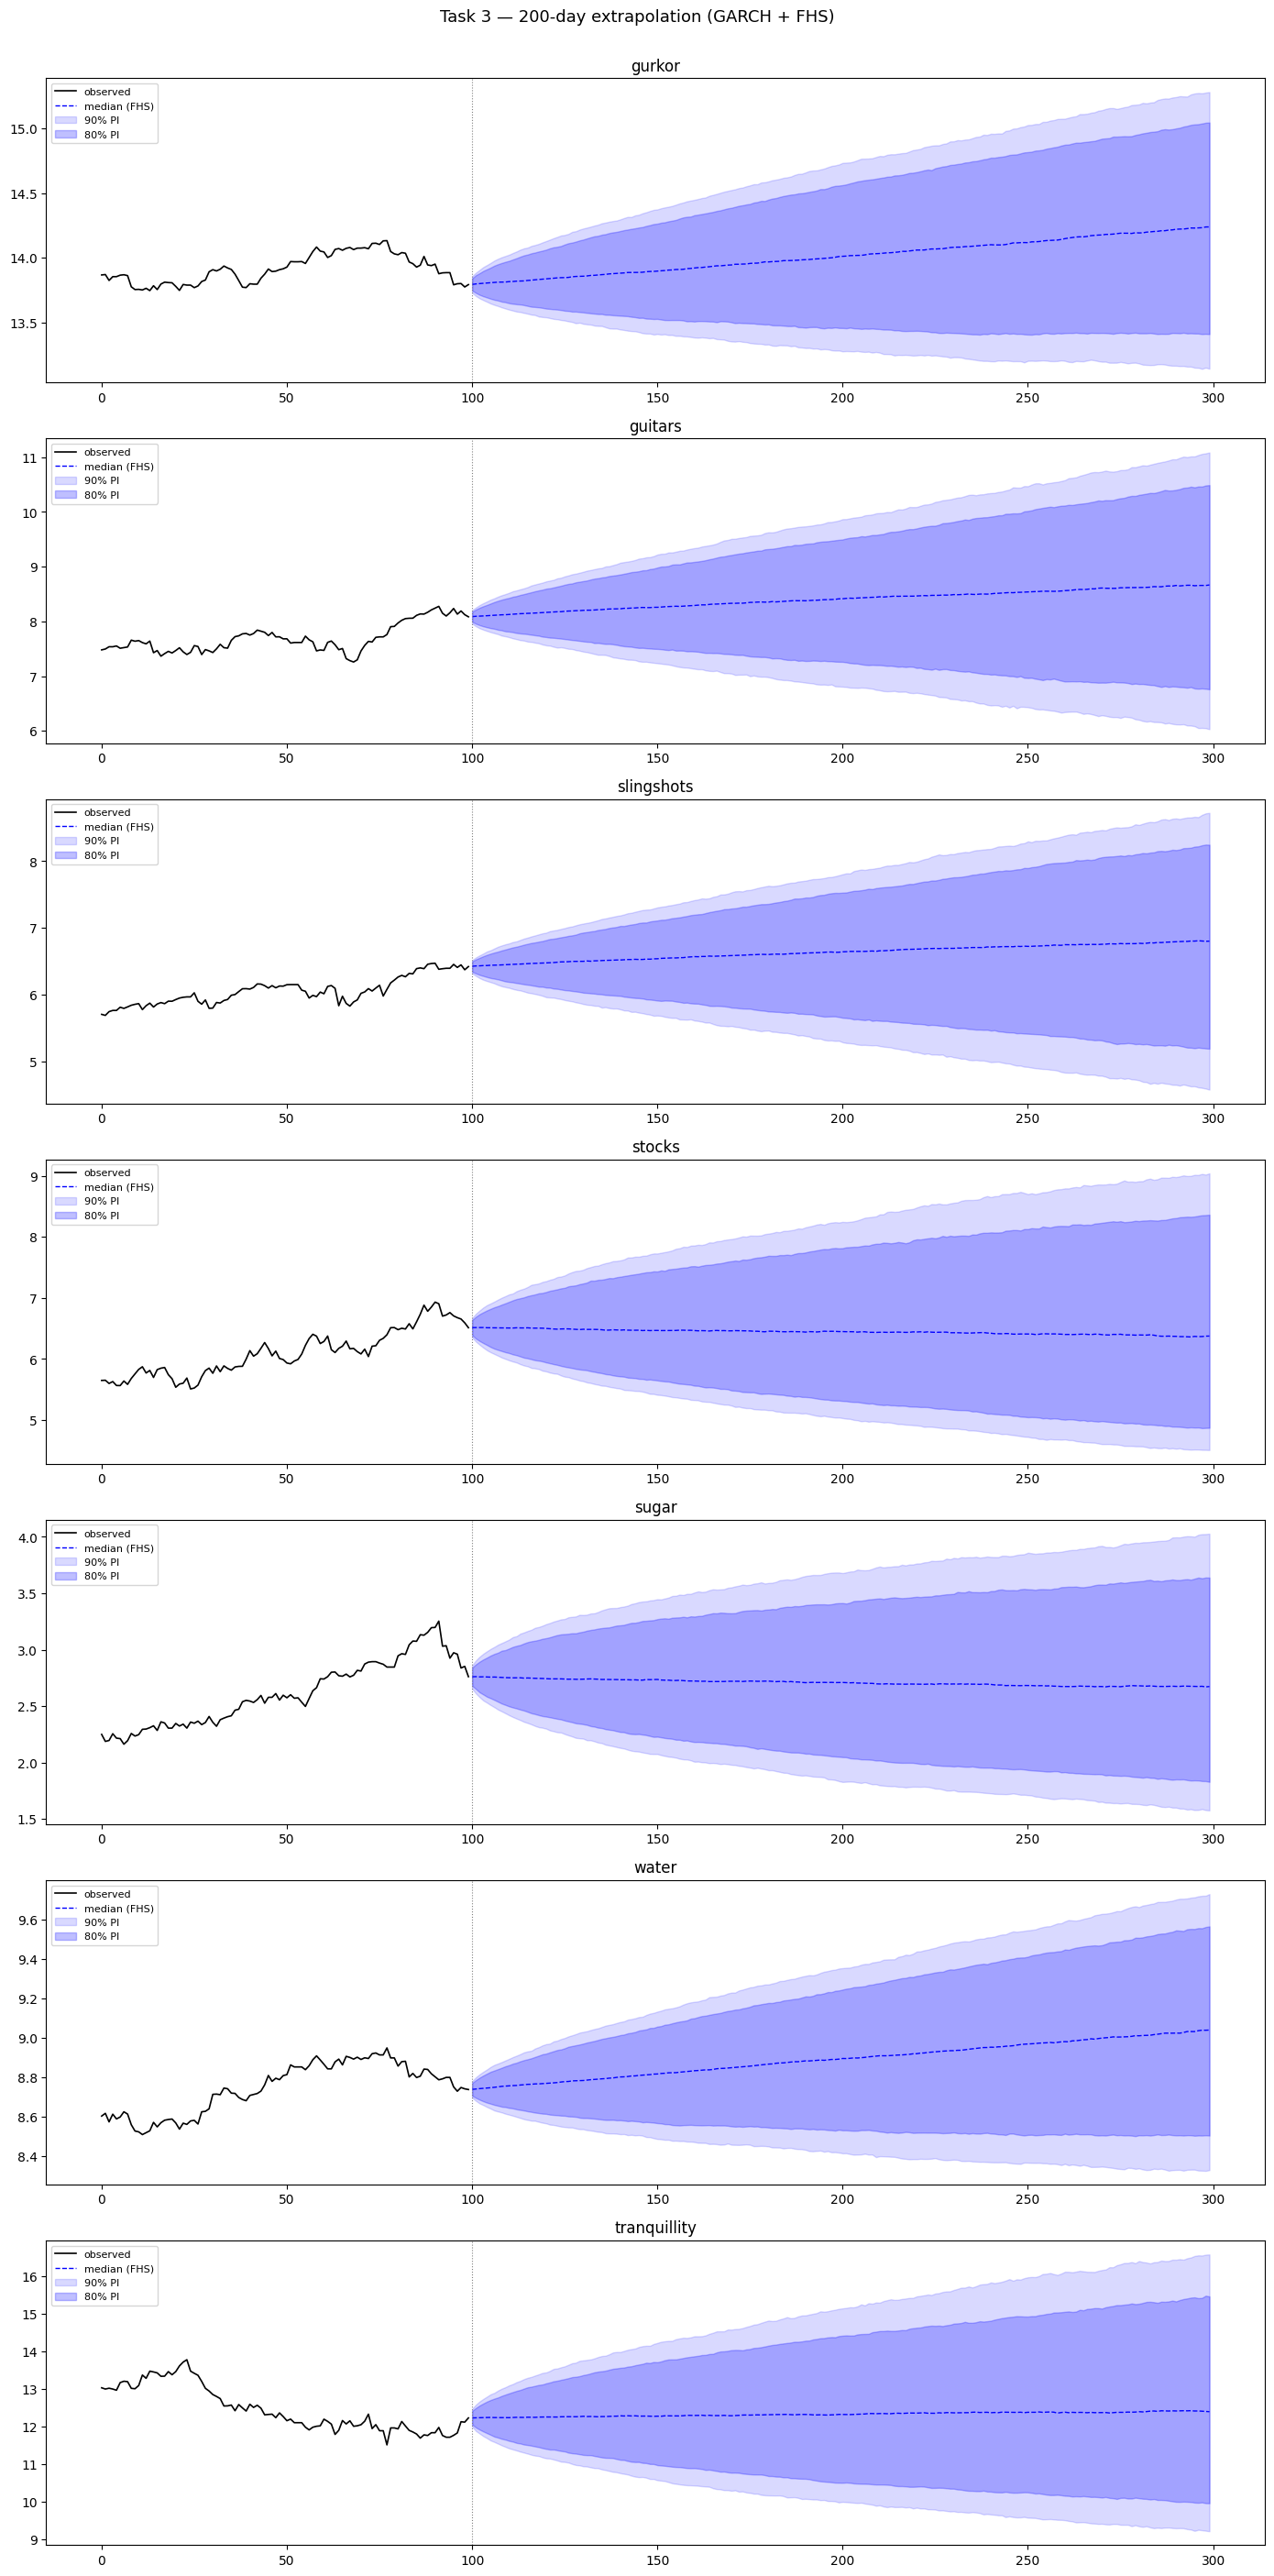

In [13]:
# Cell 14 — Final extrapolation plots using FHS (80% and 90% prediction intervals)

fig, axes = plt.subplots(len(cols), 1, figsize=(14, 28), sharex=False)
context = 100

for i, col in enumerate(cols):
    ax = axes[i]
    s  = observed[col]
    fc = forecasts_fhs[col]

    ctx   = s.iloc[-context:].values
    x_ctx = np.arange(context)
    x_fc  = np.arange(context, context + n_steps)

    ax.plot(x_ctx, ctx, 'k-', lw=1.2, label='observed')
    ax.plot(x_fc, fc['median'], 'b--', lw=1, label='median (FHS)')
    ax.fill_between(x_fc, fc['lo5'],  fc['hi95'], alpha=0.15, color='blue', label='90% PI')
    ax.fill_between(x_fc, fc['lo10'], fc['hi90'], alpha=0.25, color='blue', label='80% PI')
    ax.axvline(x=context, color='grey', ls=':', lw=0.8)
    ax.set_title(col)
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Task 3 — 200-day extrapolation (GARCH + FHS)', y=1.002, fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# Cell 15 — Export FHS forecasts to CSV

rows = []
for col in cols:
    fc = forecasts_fhs[col]
    for h in range(n_steps):
        rows.append({
            'series':  col,
            'horizon': h + 1,
            'median':  fc['median'][h],
            'pi80_lo': fc['lo10'][h],
            'pi80_hi': fc['hi90'][h],
            'pi90_lo': fc['lo5'][h],
            'pi90_hi': fc['hi95'][h],
        })

forecast_df = pd.DataFrame(rows)
forecast_df.to_csv('spiff_extrapolated.csv', index=False)
print(f'Saved {len(forecast_df)} forecast rows to spiff_extrapolated.csv')
forecast_df.groupby('series')[['median', 'pi90_lo', 'pi90_hi']].agg(['first', 'last']).round(4)

Saved 1400 forecast rows to spiff_extrapolated.csv


median           pi90_lo           pi90_hi         
                first     last    first     last    first     last
series                                                            
guitars        8.0889   8.6667   7.9597   6.0322   8.2057  11.0857
gurkor        13.7930  14.2389  13.7283  13.1403  13.8563  15.2831
slingshots     6.4235   6.8004   6.3161   4.5721   6.5139   8.7252
stocks         6.5152   6.3766   6.3534   4.5084   6.6697   9.0443
sugar          2.7600   2.6736   2.6550   1.5753   2.8602   4.0277
tranquillity  12.2315  12.3975  12.0022   9.2110  12.4728  16.5865
water          8.7393   9.0397   8.6974   8.3307   8.7810   9.7280